## 1. Mục tiêu

* Kiểm tra cấu trúc và chất lượng dữ liệu market snapshot
* Phân loại tài sản theo từng nhóm (Crypto, Forex, Stock, Index, Commodity)
* Phân tích phân phối giá và khối lượng giao dịch
* Xác định mức độ tương quan giữa các tài sản
* Rút ra insight phục vụ feature engineering và modeling ở các bước tiếp theo


## 2. Import thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from pathlib import Path



## 3. Nạp snapshot dữ liệu

In [2]:
file_path = max(
    Path("../data/snapshots").glob("market_snapshot_*.csv")
)
print("Latest snapshot:", file_path)
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("Number of Assets:", df["symbol"].nunique())

display(df.head())

Latest snapshot: ..\data\snapshots\market_snapshot_20260510_150719.csv
Dataset Shape: (71158, 8)
Number of Assets: 27


,symbol,timeframe,open,high,low,close,volume,time_timestamp
0,BTC-USD,1h,106442.296875,106513.968750,105922.125000,105923.773438,0,1762761600
1,BTC-USD,1h,105946.929688,106545.859375,105946.929688,106386.796875,2375245824,1762765200
2,BTC-USD,1h,106424.656250,106424.656250,105976.296875,106005.289062,0,1762768800
3,BTC-USD,1h,106001.789062,106283.828125,105944.421875,106184.195312,0,1762772400
4,BTC-USD,1h,106184.328125,106184.328125,105883.914062,105925.820312,1035689984,1762776000


## 4. Chuẩn bị dữ liệu
- Chuyển đổi timestamp sang datetime.
- Phân loại tài sản thành Crypto, Forex, Stock, Index và Commodity.

In [3]:
df["datetime"] = pd.to_datetime(
    df["time_timestamp"],
    unit="s"
)


def classify_asset(symbol: str) -> str:

    if "-USD" in symbol:
        return "Crypto"

    if symbol.startswith("^"):
        return "Index"

    if symbol in ["GC=F", "SI=F", "XAUUSD=X", "XAGUSD=X"]:
        return "Commodity"

    if "=X" in symbol:
        return "Forex"

    return "Stock"


df["asset_class"] = df["symbol"].apply(
    classify_asset
)


print("Asset Classes:")
print(df["asset_class"].value_counts())

Asset Classes:
asset_class
Crypto       38916
Forex        18196
Stock         5957
Commodity     5536
Index         2553
Name: count, dtype: int64


In [4]:
df_returns = df.sort_values(["symbol", "datetime"]).copy()
df_returns["daily_return"] = df_returns.groupby("symbol")["close"].pct_change()
df_returns = df_returns.dropna(subset=["daily_return"]).reset_index(drop=True)

print("Prepared returns dataset:", df_returns.shape)
display(df_returns[["symbol", "datetime", "daily_return", "asset_class"]].head())

Prepared returns dataset: (71131, 11)


,symbol,datetime,daily_return,asset_class
0,AAPL,2025-11-10 15:30:00,-0.010265,Stock
1,AAPL,2025-11-10 16:30:00,0.000050,Stock
2,AAPL,2025-11-10 17:30:00,0.002416,Stock
3,AAPL,2025-11-10 18:30:00,-0.000260,Stock
4,AAPL,2025-11-10 19:30:00,-0.002008,Stock


## 5. Phân tích giá
- Tính các thống kê giá cơ bản (mean, std, min, max, CV).
- Phân tích biểu đồ Tỷ suất sinh lợi giữa các nhóm tài sản.

### 5.1 Thống kê giá
Tính toán các thống kê mô tả cho **giá đóng cửa** của từng tài sản nhằm đánh giá mức giá trung bình và độ biến động tổng quan.

In [5]:
price_stats = (
    df.groupby("symbol")["close"]
    .agg(
        count="count",
        mean="mean",
        std="std",
        min="min",
        max="max"
    )
)
price_stats["CV"] = price_stats["std"] / price_stats["mean"]
price_stats = price_stats.sort_values("CV", ascending=False)

display(price_stats)

,count,mean,std,min,max,CV
symbol,,,,,,
ADA-USD,4324,0.326833,0.080460,0.236241,0.600391,0.246181
SOL-USD,4324,107.494776,24.602001,75.550331,169.978546,0.228867
AVAX-USD,4324,11.171698,2.300483,8.235131,18.341276,0.205921
DOGE-USD,4324,0.116174,0.023526,0.087463,0.184226,0.202506
XRP-USD,4324,1.692147,0.337315,1.156400,2.566082,0.199341
LINK-USD,4324,10.890426,2.149292,7.906779,16.649693,0.197356
ETH-USD,4324,2556.773012,483.011166,1816.646240,3622.248779,0.188914
SI=F,2768,75.387058,13.740768,48.395000,119.385002,0.182270
BNB-USD,4324,747.444947,131.404753,572.708435,1003.820007,0.175805


#### **Nhận xét bảng thống kê mô tả**

Bảng thống kê mô tả cho thấy những khác biệt khá rõ giữa các nhóm tài sản trong bộ dữ liệu, bao gồm tiền điện tử, cổ phiếu, chỉ số chứng khoán, hàng hóa và ngoại hối. Thông qua các chỉ tiêu như số lượng quan sát, giá trị trung bình, khoảng biến động và hệ số biến thiên (CV), có thể rút ra một số đặc điểm đáng chú ý như sau:

##### **1. Đặc điểm về số lượng quan sát và tần suất giao dịch**

Số lượng quan sát (`count`) phản ánh tương đối rõ đặc điểm hoạt động của từng thị trường.

* **Nhóm tiền điện tử:** Các tài sản như **Bitcoin**, **Ethereum** hay **Solana** đều có khoảng 4324 ngày quan sát, cao nhất trong toàn bộ tập dữ liệu. Điều này phù hợp với đặc điểm của thị trường tiền điện tử khi giao dịch diễn ra liên tục 24 giờ mỗi ngày và 7 ngày trong tuần, không bị giới hạn bởi ngày nghỉ.

* **Nhóm cổ phiếu và chỉ số chứng khoán:** Các mã như **Apple Inc.**, **Microsoft Corporation**, **Dow Jones Industrial Average** hay **S&P 500 Index** chỉ có khoảng 851 phiên giao dịch. Điều này xuất phát từ việc các thị trường chứng khoán hoạt động theo giờ giao dịch cố định và nghỉ vào cuối tuần cũng như các ngày lễ.

* **Nhóm ngoại hối và hàng hóa:** Số lượng quan sát nằm trong khoảng 2700–3000 phiên, cho thấy các thị trường này hoạt động gần như liên tục trong tuần nhưng vẫn có thời gian nghỉ vào cuối tuần.

Nhìn chung, sự khác biệt về số lượng quan sát phản ánh khá rõ đặc trưng vận hành của từng loại thị trường.

##### **2. Mặt bằng giá trị và biên độ dao động tuyệt đối**

Giá trị trung bình của các tài sản cho thấy sự khác biệt lớn về mặt bằng giá giữa các nhóm.

* **Nhóm có mức giá cao:** **Bitcoin** có mức giá trung bình trên 80.000 USD, dao động trong khoảng từ 62.704 USD đến 106.548 USD, cao nhất trong nhóm tài sản được nghiên cứu. Bên cạnh đó, các chỉ số như **Dow Jones Industrial Average** hay **NASDAQ Composite** cũng có giá trị tuyệt đối khá lớn.

* **Nhóm có mức giá thấp:** Một số đồng tiền điện tử khác như **Dogecoin** hay **Cardano** có mức giá trung bình dưới 1 USD. Điều này cho thấy sự phân hóa rất lớn về mệnh giá ngay cả trong cùng một nhóm tài sản.

Tuy nhiên, giá trị tuyệt đối không phản ánh đầy đủ mức độ rủi ro, do đó cần kết hợp thêm các chỉ tiêu về biến động tương đối.

##### **3. So sánh mức độ rủi ro thông qua hệ số biến thiên (CV)**

Hệ số biến thiên (Coefficient of Variation – CV) được sử dụng để đánh giá mức độ biến động tương đối giữa các tài sản có mặt bằng giá khác nhau. Kết quả cho thấy có thể phân thành một số nhóm rủi ro chính:

* **Nhóm rủi ro cao – Tiền điện tử:**

  * Các đồng tiền điện tử có mức CV cao nhất trong toàn bộ mẫu nghiên cứu. Đặc biệt, **Cardano**, **Solana** và **Avalanche** đều có hệ số CV trên 20%, cho thấy mức biến động rất lớn.

  * Ngay cả **Bitcoin** và **Ethereum**, vốn được xem là các tài sản có quy mô lớn trong thị trường tiền điện tử, cũng có mức CV cao hơn đáng kể so với phần lớn các tài sản truyền thống. Kết quả này cho thấy nhóm tiền điện tử vẫn là nhóm có mức độ rủi ro tương đối cao.

* **Nhóm rủi ro trung bình – Cổ phiếu và kim loại quý:**

  * Trong nhóm hàng hóa, bạc (**Silver Futures**) có mức biến động tương đối cao hơn vàng (**Gold Futures**). Điều này cho thấy dù cùng thuộc nhóm kim loại quý, mức độ ổn định giữa các tài sản vẫn có sự khác biệt.

  * Đối với cổ phiếu công nghệ như **Microsoft Corporation**, **Amazon.com, Inc.**, **Tesla, Inc.** hay **Alphabet Inc.**, hệ số CV dao động trong khoảng 7%–10%. Mức biến động này phản ánh đặc điểm của nhóm cổ phiếu tăng trưởng, có tiềm năng sinh lời cao nhưng vẫn đi kèm rủi ro thị trường và rủi ro doanh nghiệp.

* **Nhóm rủi ro thấp – Chỉ số thị trường:**

  * Các chỉ số như **NASDAQ Composite**, **S&P 500 Index** và **Dow Jones Industrial Average** đều có mức CV tương đối thấp, dưới khoảng 4%.

  * Kết quả này khá phù hợp với đặc điểm của các chỉ số thị trường, khi giá trị của chúng được hình thành từ nhiều doanh nghiệp khác nhau. Nhờ hiệu ứng đa dạng hóa, mức biến động chung thường thấp hơn so với từng cổ phiếu riêng lẻ.

* **Nhóm biến động thấp nhất – Ngoại hối:**

  * Các cặp tỷ giá như **EUR/USD**, **USD/CAD** và **USD/JPY** có hệ số CV chỉ dao động quanh mức 1%–2%.

  * Điều này cho thấy thị trường ngoại hối có mức biến động tương đối thấp hơn so với các nhóm tài sản khác trong bộ dữ liệu, phù hợp với đặc điểm của thị trường tiền tệ quốc tế.

##### **Kết luận**

Từ các chỉ tiêu thống kê mô tả, có thể thấy mỗi nhóm tài sản đều mang những đặc điểm riêng về tần suất giao dịch, mặt bằng giá và mức độ biến động. Nhóm tiền điện tử thể hiện mức biến động cao nhất, đi kèm khả năng sinh lời và rủi ro lớn. Nhóm cổ phiếu và hàng hóa nằm ở mức trung bình, trong khi các chỉ số thị trường và ngoại hối có xu hướng ổn định hơn. Kết quả này tương đối phù hợp với đặc điểm chung của các thị trường tài chính và cũng cung cấp cơ sở ban đầu cho các phân tích sâu hơn ở các phần tiếp theo.


### 5.2 Biểu đồ Tỷ suất sinh lợi
Trực quan hóa phân bố mức sinh lời giữa các nhóm tài sản.

Biểu đồ giúp quan sát:

* **Biên độ sinh lời:** Khoảng biến thiên của tỷ suất sinh lợi (từ mức lỗ sâu nhất đến mức lãi cao nhất).
* **Mức độ phân tán (Rủi ro):** Tần suất phân bố của tỷ suất sinh lợi, qua đó đánh giá mức độ biến động và rủi ro của từng loại tài sản.
* **Sự khác biệt về hiệu suất:** So sánh tương quan về khả năng sinh lời và đặc tính rủi ro giữa các thị trường khác nhau.

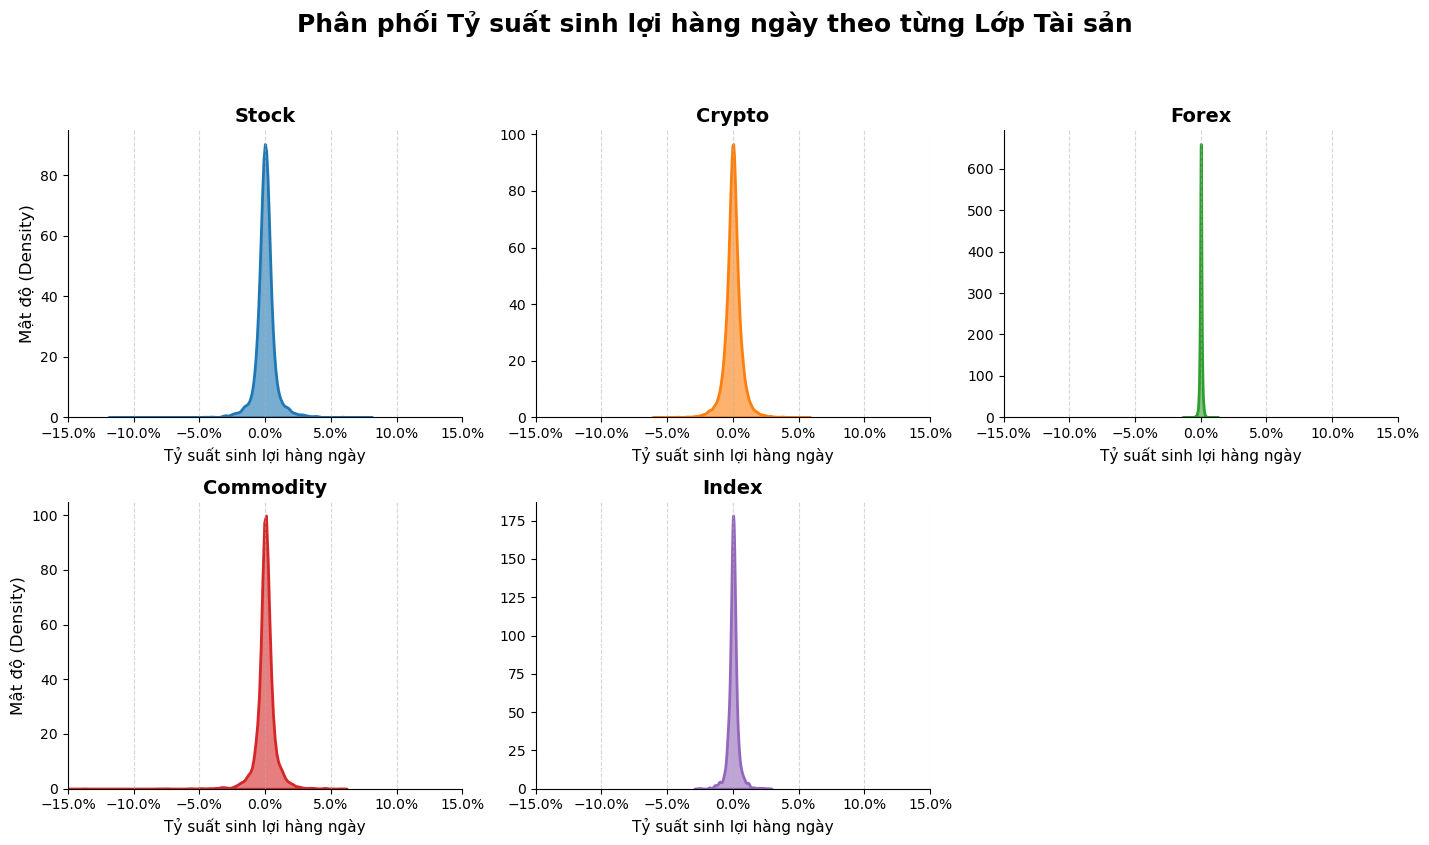

In [6]:
g = sns.FacetGrid(
    df_returns, 
    col="asset_class", 
    hue="asset_class", 
    col_wrap=3, 
    height=4, 
    aspect=1.2, 
    sharey=False,
    sharex=False 
)

g.map_dataframe(
    sns.kdeplot, 
    x='daily_return', 
    fill=True, 
    alpha=0.6, 
    linewidth=2
)

g.fig.suptitle(
    "Phân phối Tỷ suất sinh lợi hàng ngày theo từng Lớp Tài sản", 
    fontsize=18, 
    fontweight='bold', 
    y=1.05
)

g.set_titles(col_template="{col_name}", size=14, fontweight='bold')
g.set_axis_labels("", "Mật độ (Density)", fontsize=12) # Tạm làm rỗng nhãn X ở đây để set chi tiết bên dưới

g.set(xlim=(-0.15, 0.15))

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
    ax.set_xlabel("Tỷ suất sinh lợi hàng ngày", fontsize=11)
    ax.tick_params(labelbottom=True) 
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### **NHẬN XÉT BIỂU ĐỒ PHÂN PHỐI TỶ SUẤT SINH LỢI HÀNG NGÀY**

Biểu đồ phân phối mật độ cho thấy sự khác biệt khá rõ về mức độ biến động giữa 5 nhóm tài sản gồm **ngoại hối, chỉ số chứng khoán, cổ phiếu, hàng hóa và tiền điện tử**. Thông qua hình dạng của đường phân phối, mức độ tập trung quanh giá trị trung bình và độ mở rộng của hai phía đuôi phân phối, có thể rút ra một số nhận xét như sau:

##### **1. Nhóm cổ phiếu (Stock)**

* **Đặc điểm phân phối:**

  * Đường phân phối có **đỉnh thấp hơn** so với nhóm Index.
  * Phần đuôi phân phối mở rộng hơn về cả hai phía.

* **Nhận xét:**

  * Điều này cho thấy tỷ suất sinh lợi hàng ngày của cổ phiếu riêng lẻ có **mức phân tán lớn hơn**, đồng nghĩa với mức độ biến động và rủi ro cao hơn so với chỉ số thị trường.
  * Xác suất xuất hiện các phiên tăng hoặc giảm mạnh cũng cao hơn.

* **Giải thích:**

  * Giá cổ phiếu không chỉ chịu ảnh hưởng từ xu hướng chung của thị trường mà còn chịu tác động bởi:

    * **Kết quả kinh doanh**
    * **Chiến lược phát triển doanh nghiệp**
    * **Thông tin tài chính**
    * **Tâm lý nhà đầu tư**

##### **2. Nhóm tiền điện tử (Crypto)**

* **Đặc điểm phân phối:**

  * Đây là nhóm có **đường phân phối trải rộng nhất** trong toàn bộ mẫu nghiên cứu.
  * Đỉnh phân phối thấp hơn, trong khi phần đuôi kéo dài đáng kể về cả hai phía.

* **Nhận xét:**

  * Điều này cho thấy tỷ suất sinh lợi hàng ngày của nhóm tiền điện tử có **mức phân tán rất lớn**.
  * Xác suất xuất hiện các phiên tăng mạnh hoặc giảm mạnh cao hơn rõ rệt so với các nhóm tài sản khác.
  * Đây là nhóm có **mức độ biến động và rủi ro cao nhất** trong bộ dữ liệu.

* **Giải thích:**

  * Kết quả này phản ánh đúng đặc điểm của thị trường tiền điện tử khi giá tài sản thường chịu ảnh hưởng mạnh từ:

    * **Tâm lý nhà đầu tư**
    * **Dòng tiền đầu cơ**
    * **Tin tức thị trường**
    * **Mức độ chấp nhận công nghệ và thanh khoản**


##### **3. Nhóm ngoại hối (Forex)**

* **Đặc điểm phân phối:**

  * Đường phân phối có **đỉnh rất cao** và tập trung mạnh quanh mức tỷ suất sinh lợi bằng **0%**.
  * Phần đuôi phân phối **khá hẹp**, ít lan rộng sang hai phía.

* **Nhận xét:**

  * Điều này cho thấy tỷ suất sinh lợi hàng ngày của các cặp tiền tệ thường dao động trong **phạm vi nhỏ** và ít xuất hiện những phiên biến động mạnh.
  * So với các nhóm tài sản còn lại, **Forex là nhóm có mức biến động thấp nhất**.

* **Giải thích:**

  * Kết quả này phù hợp với đặc điểm của thị trường ngoại hối, khi giá trị tiền tệ chủ yếu chịu ảnh hưởng từ **các yếu tố kinh tế vĩ mô, chính sách tiền tệ và hoạt động điều tiết của ngân hàng trung ương**.
  * Vì vậy, biến động ngắn hạn thường tương đối ổn định.

##### **4. Nhóm hàng hóa (Commodity)**

* **Đặc điểm phân phối:**

  * Đường phân phối có hình dạng khá tương đồng với nhóm cổ phiếu.
  * Mức độ phân tán ở mức trung bình và phần đuôi phân phối rộng hơn so với nhóm Index.

* **Nhận xét:**

  * Điều này cho thấy giá hàng hóa có **mức biến động tương đối đáng kể trong ngắn hạn**.
  * Rủi ro của nhóm này cao hơn chỉ số thị trường nhưng vẫn thấp hơn so với tiền điện tử.

* **Giải thích:**

  * Biến động giá hàng hóa thường chịu ảnh hưởng bởi nhiều yếu tố như:

    * **Cung – cầu toàn cầu**
    * **Lạm phát**
    * **Lãi suất**
    * **Biến động địa chính trị**
    * **Chu kỳ kinh tế**

##### **5. Nhóm chỉ số thị trường (Index)**

* **Đặc điểm phân phối:**

  * Đường phân phối có **đỉnh tương đối cao**, tập trung quanh mức trung bình.
  * Độ phân tán lớn hơn nhóm Forex nhưng vẫn nằm trong phạm vi khá hẹp.

* **Nhận xét:**

  * Phần lớn tỷ suất sinh lợi hàng ngày của nhóm này nằm trong một khoảng dao động tương đối ổn định.
  * So với cổ phiếu riêng lẻ, **các chỉ số thị trường ít xuất hiện biến động cực đoan hơn**.

* **Giải thích:**

  * Điều này phù hợp với bản chất của chỉ số thị trường khi được cấu thành từ **nhiều doanh nghiệp thuộc nhiều lĩnh vực khác nhau**.
  * Nhờ hiệu ứng **đa dạng hóa danh mục**, các biến động mạnh của từng cổ phiếu riêng lẻ có xu hướng được giảm bớt khi phản ánh vào chỉ số chung.




**KẾT LUẬN**

Từ biểu đồ phân phối tỷ suất sinh lợi hàng ngày, có thể thấy mức độ biến động giữa các nhóm tài sản có sự khác biệt khá rõ:

* **Ngoại hối (Forex):** Có phân phối tập trung nhất → **mức độ ổn định cao, rủi ro thấp**.
* **Chỉ số thị trường (Index):** Biến động thấp nhờ **hiệu ứng đa dạng hóa**.
* **Cổ phiếu (Stock) và Hàng hóa (Commodity):** Có mức phân tán lớn hơn → **rủi ro ở mức trung bình**.
* **Tiền điện tử (Crypto):** Phân phối rộng nhất, đuôi phân phối dài → **mức độ biến động và rủi ro cao nhất**.


## 6. Phân tích khối lượng giao dịch
Khối lượng giao dịch *(Volume)* phản ánh **mức độ thanh khoản** và **dòng tiền** của từng loại tài sản. Tuy nhiên, do dữ liệu được thu thập từ nhiều thị trường khác nhau, cần thực hiện bước làm sạch dữ liệu trước khi phân tích nhằm đảm bảo tính so sánh và độ tin cậy của kết quả.

Các vấn đề chính cần xử lý gồm:

* **Khác biệt về đơn vị đo lường:**
  `Volume` gốc chỉ thể hiện số lượng tài sản được giao dịch, chưa phản ánh quy mô dòng tiền thực tế. Vì vậy, khối lượng được quy đổi sang **giá trị giao dịch theo USD**:

$$Volume_{USD}=Close\times Volume$$

* **Dữ liệu Forex không đầy đủ:**
  Do thị trường ngoại hối hoạt động phi tập trung *(OTC)*, dữ liệu `Volume` từ API thường bằng `0` hoặc bị thiếu, nên nhóm này được loại khỏi phân tích.

* **Giá trị ngoại lai và nhiễu dữ liệu:**
  Một số quan sát có `Volume = 0` hoặc xuất hiện các giá trị bất thường do lỗi thu thập dữ liệu, cần được loại bỏ.

**Mục tiêu của bước xử lý dưới đây** là xây dựng tập dữ liệu thanh khoản đã làm sạch (`df_volume_clean`) bằng cách **loại bỏ Forex, các giá trị bằng 0 và các ngoại lai cực đoan**, từ đó phục vụ cho phân tích thống kê và trực quan hóa bằng biểu đồ Boxplot.


Bảng Thống kê Giá trị Giao dịch (Volume USD):


,mean,std,min,max
asset_class,,,,
Crypto,8.380263e+12,3.578175e+13,1.015493e+02,4.953020e+14
Index,7.340326e+12,8.172211e+12,2.596558e+11,1.281905e+14
Stock,1.705593e+09,1.660556e+09,3.247208e+07,1.916140e+10
Commodity,2.031823e+07,3.387549e+07,9.165000e+01,6.471763e+08


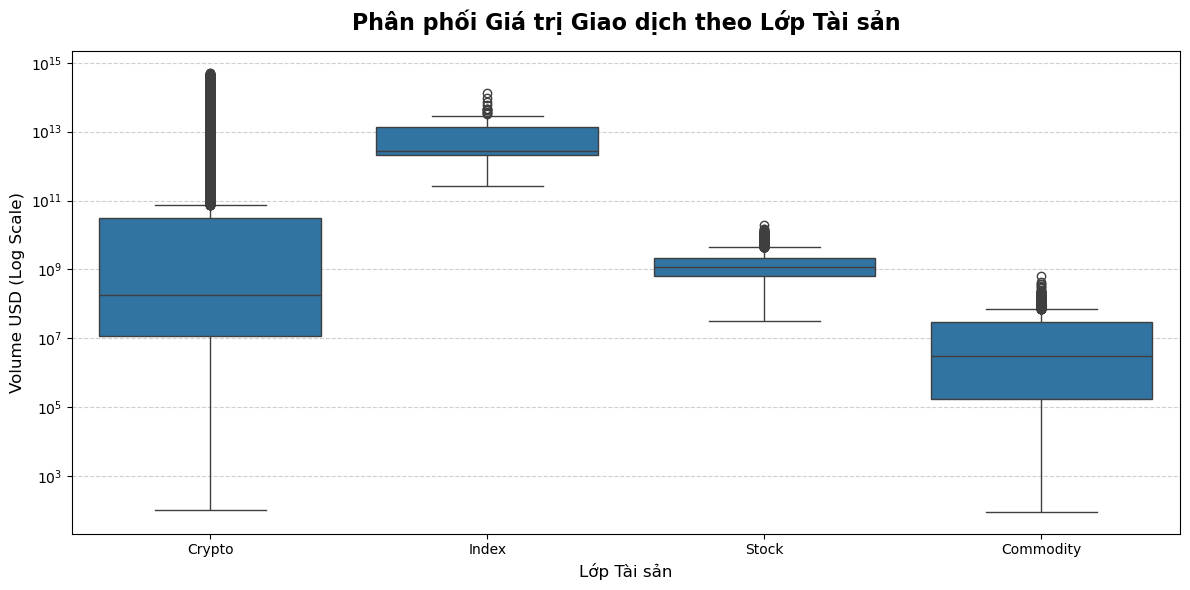

In [7]:
df_volume = df[df['asset_class'] != 'Forex'].copy()
df_volume = df_volume[df_volume['volume'] > 0]
df_volume['volume_usd'] = df_volume['close'] * df_volume['volume']
threshold = df_volume['volume_usd'].quantile(0.999) 
df_volume_clean = df_volume[df_volume['volume_usd'] < threshold]

volume_stats = df_volume_clean.groupby('asset_class')['volume_usd'].agg(['mean', 'std', 'min', 'max'])
print("Bảng Thống kê Giá trị Giao dịch (Volume USD):")
display(volume_stats.sort_values('mean', ascending=False))

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_volume_clean, x='asset_class', y='volume_usd')

plt.yscale('log')
plt.title("Phân phối Giá trị Giao dịch theo Lớp Tài sản", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Lớp Tài sản", fontsize=12)
plt.ylabel("Volume USD (Log Scale)", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### **Nhận xét phân phối khối lượng giao dịch (Volume USD)**

* **Index và Crypto là hai nhóm có thanh khoản cao nhất**, với giá trị giao dịch trung bình đều đạt mức rất lớn *(khoảng $10^{12}$ USD)*. Tuy nhiên, đặc điểm phân phối của hai nhóm này có sự khác biệt rõ rệt:

  * **Index:** Boxplot có hộp phân phối hẹp và râu ngắn, cho thấy khối lượng giao dịch tương đối ổn định giữa các phiên.
  * **Crypto:** Boxplot có độ phân tán lớn, râu dài và xuất hiện nhiều điểm ngoại lai, phản ánh dòng tiền biến động mạnh và thanh khoản không đồng đều theo thời gian.

* **Sự phân tầng về quy mô thanh khoản khá rõ rệt** giữa các nhóm tài sản:

  * **Stock** có khối lượng giao dịch thấp hơn đáng kể so với Index nhưng phân phối tương đối tập trung.
  * **Commodity** là nhóm có giá trị giao dịch thấp nhất trong mẫu nghiên cứu.

* **Về mức độ biến động thanh khoản**, nhóm **Crypto** có độ lệch chuẩn lớn nhất, cho thấy dòng tiền thay đổi mạnh giữa các phiên giao dịch. Kết quả này tiếp tục cho thấy đây là nhóm tài sản có mức biến động cao và rủi ro lớn hơn so với các thị trường truyền thống.



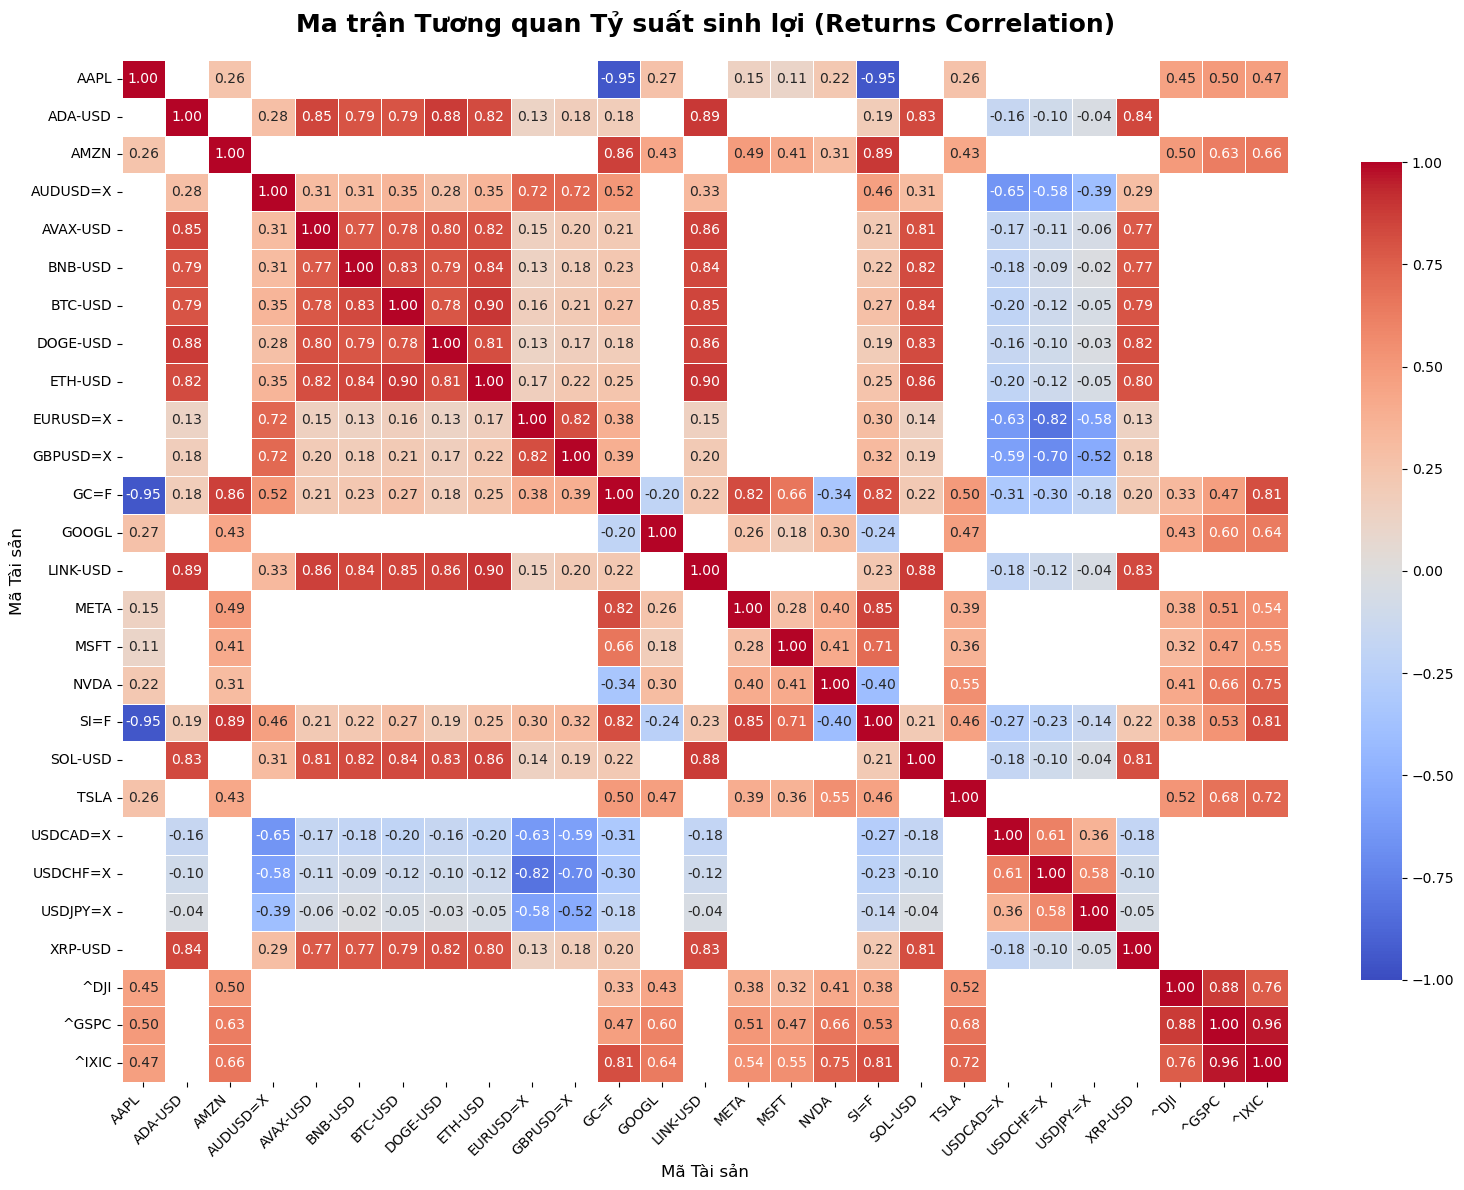

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuyển đổi Unix timestamp sang định dạng Datetime chuẩn
# Đặt tên cột mới là 'datetime'
df['datetime'] = pd.to_datetime(df['time_timestamp'], unit='s')

# 2. (Tùy chọn nhưng quan trọng) Tính lại daily_return nếu bạn chưa tính đúng cách
# Đảm bảo dữ liệu được sắp xếp theo thời gian trước khi tính % thay đổi
df = df.sort_values(by=['symbol', 'datetime'])
df['daily_return'] = df.groupby('symbol')['close'].pct_change()

# 3. Pivot dữ liệu: Dùng cột 'datetime' vừa tạo làm dòng, 'symbol' làm cột
returns_pivot = df.pivot_table(index='datetime', columns='symbol', values='daily_return')

# 4. Tính Ma trận tương quan (Pearson)
corr_matrix = returns_pivot.corr()

# 5. Vẽ biểu đồ Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    annot=True,        # Bật lại annot=True để hiện các con số tương quan
    cmap='coolwarm', 
    fmt=".2f",
    linewidths=0.5, 
    vmin=-1, vmax=1,   # Ép buộc thang màu chạy từ -1 đến 1
    cbar_kws={"shrink": .8}
)

plt.title("Ma trận Tương quan Tỷ suất sinh lợi (Returns Correlation)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Mã Tài sản", fontsize=12)
plt.ylabel("Mã Tài sản", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### **Nhận xét:**

Dựa trên ma trận tương quan *(Correlation Heatmap)* của tỷ suất sinh lợi, có thể nhận thấy một số mối quan hệ đáng chú ý giữa các nhóm tài sản như sau:

##### **1. Nhóm tiền điện tử (Crypto)**

* Các đồng tiền điện tử như **Bitcoin**, **Ethereum**, **BNB**, **Solana** và **Cardano** có mức tương quan thuận rất cao, với phần lớn hệ số tương quan đều lớn hơn **0.8**.

* Điều này cho thấy các tài sản trong nhóm Crypto thường biến động cùng chiều và chịu ảnh hưởng mạnh từ xu hướng chung của thị trường, đặc biệt là từ **Bitcoin**.

* Kết quả này cho thấy các biến như giá hoặc tỷ suất sinh lợi của BTC có thể là một biến đầu vào quan trọng khi xây dựng mô hình dự báo cho các Altcoin.

##### **2. Nhóm chỉ số chứng khoán Mỹ (Index)**

* Các chỉ số **Dow Jones Industrial Average**, **S&P 500 Index** và **NASDAQ Composite** có tương quan thuận mạnh, với hệ số tương quan dao động từ **0.76 đến 0.96**.

* Điều này cho thấy các chỉ số đại diện cho thị trường chứng khoán Mỹ có xu hướng biến động tương đối đồng pha và cùng phản ánh bối cảnh kinh tế chung.

* Khi xây dựng mô hình dự báo, có thể lựa chọn một chỉ số đại diện để tránh hiện tượng **đa cộng tuyến *(multicollinearity)***.


##### **3. Nhóm ngoại hối (Forex)**

* Một số cặp tỷ giá như **USD/CAD** có tương quan âm với **EUR/USD** và **GBP/USD**.

* Kết quả này phù hợp với đặc điểm của thị trường ngoại hối, khi vai trò của đồng **USD** trong từng cặp tiền là khác nhau.

* Khi sức mạnh của USD tăng, các cặp có USD đứng trước thường tăng, trong khi các cặp có USD đứng sau có xu hướng giảm.

##### **4. Nhóm cổ phiếu công nghệ (Big Tech)**

* Các cổ phiếu công nghệ lớn như **Microsoft Corporation**, **Alphabet Inc.**, **Amazon.com, Inc.**, **Meta Platforms, Inc.**, **NVIDIA Corporation** và **Tesla, Inc.** có mức tương quan nội nhóm ở mức **trung bình đến mạnh**, với hệ số dao động khoảng **0.40–0.66**.

* Bên cạnh đó, nhóm này cũng có mức tương quan khá cao với các chỉ số thị trường, đặc biệt là **NASDAQ Composite**.

* Kết quả này cho thấy nhóm Big Tech có vai trò quan trọng trong việc dẫn dắt xu hướng của thị trường chứng khoán Mỹ, đặc biệt đối với các chỉ số thiên về công nghệ.

* Trong các mô hình dự báo chỉ số thị trường, biến động của nhóm Big Tech có thể là nhóm biến đầu vào có giá trị giải thích cao.

##### **5. Nhóm kim loại quý và hàng hóa (Precious Metals)**

* **Gold Futures** và **Silver Futures** có tương quan thuận mạnh, với hệ số tương quan khoảng **0.82**.

* Điều này cho thấy hai tài sản này thường biến động cùng chiều và phản ứng tương đối giống nhau trước các yếu tố kinh tế vĩ mô như lạm phát, lãi suất hoặc bất ổn thị trường.

* Kết quả này phù hợp với vai trò của vàng và bạc như các **tài sản trú ẩn *(safe-haven assets)*** trong giai đoạn thị trường có mức độ bất định cao.

* Khi xây dựng mô hình đa biến, có thể sử dụng một trong hai tài sản làm biến đại diện cho nhóm tài sản phòng thủ.

##### **6. Một số mối tương quan bất thường**

* Ma trận tương quan cho thấy **Apple Inc.** có tương quan âm mạnh với **Gold Futures** và **Silver Futures**.

* Về mặt kinh tế, mối quan hệ nghịch chiều giữa cổ phiếu tăng trưởng và tài sản trú ẩn là hợp lý. Tuy nhiên, hệ số tương quan tuyệt đối cao bất thường có thể chịu ảnh hưởng bởi:

  * Sự khác biệt về thời gian giao dịch giữa các thị trường.
  * Sai lệch trong quá trình đồng bộ dữ liệu.
  * Đặc điểm của khoảng thời gian quan sát.

* Do đó, các cặp tài sản này cần được kiểm tra thêm ở các bước phân tích chuỗi thời gian tiếp theo.

---

##### **Kết luận**

Kết quả phân tích tương quan cho thấy các tài sản trong cùng nhóm thị trường thường có xu hướng biến động cùng chiều, đặc biệt rõ ở nhóm **Crypto**, **Index**, **Big Tech** và **kim loại quý**. Trong khi đó, nhóm **Forex** thể hiện cả tương quan thuận và nghịch tùy theo cấu trúc cặp tiền. Những kết quả này không chỉ phản ánh đặc điểm vận động của từng thị trường mà còn cung cấp cơ sở quan trọng cho việc lựa chọn biến đầu vào trong các mô hình dự báo tiếp theo.



## **7. Tổng kết**

Sau quá trình phân tích khám phá dữ liệu *(EDA)* về giá, khối lượng giao dịch và mối tương quan giữa các nhóm tài sản, có thể rút ra một số kết luận chính như sau:

### **7.1. Những phát hiện chính**

* **Sự phân tầng rủi ro rõ rệt:**

  * **Crypto** là nhóm có mức biến động cao nhất, thể hiện qua hệ số biến thiên *(CV)* lớn và phân phối tỷ suất sinh lợi có đuôi dày.
  * **Forex** và **Index** có mức biến động thấp hơn, cho thấy tính ổn định tương đối cao.

* **Đặc điểm thanh khoản:**

  * **Index** và **Crypto** là hai nhóm có giá trị giao dịch lớn nhất.
  * Dòng tiền của **Index** tương đối ổn định, trong khi **Crypto** có mức biến động thanh khoản lớn và xuất hiện nhiều đột biến.
  * Dữ liệu `Volume` của **Forex** không đầy đủ do đặc điểm thị trường OTC và cần được xử lý riêng.

* **Mối tương quan giữa các thị trường:**

  * Nhóm **Crypto** và **Index** có tương quan nội nhóm cao.
  * Nhóm **Big Tech** có mối liên hệ chặt chẽ với các chỉ số chứng khoán Mỹ.
  * **Vàng** và **Bạc** có tương quan thuận mạnh, phản ánh vai trò của nhóm tài sản phòng thủ.

### **7.2. Định hướng xây dựng mô hình**

Dựa trên các đặc điểm đã quan sát, chiến lược xây dựng mô hình ở các bước tiếp theo sẽ tập trung vào:

#### **a. Tiền xử lý và tạo biến**

* Xử lý các giá trị ngoại lai, đặc biệt ở nhóm **Crypto**.
* Đồng bộ chuỗi thời gian giữa các thị trường bằng phương pháp `Forward Fill`.
* Lựa chọn các biến đầu vào dựa trên kết quả phân tích tương quan nhằm giảm nhiễu và hạn chế đa cộng tuyến.

#### **b. Lựa chọn mô hình dự báo**

* **ARIMA/SARIMA:** Phù hợp với nhóm **Index** và **Forex** nhờ mức độ ổn định cao.
* **Prophet:** Phù hợp với các tài sản có yếu tố xu hướng hoặc mùa vụ.
* **Deep Learning / Hybrid Models:** Phù hợp với nhóm **Crypto** do đặc điểm biến động phi tuyến và rủi ro cao.

#### **c. Đánh giá mô hình**

* Mô hình sẽ được đánh giá thông qua các chỉ số sai số như **RMSE**, **MAE**, đồng thời xem xét khả năng phản ứng với các giai đoạn biến động mạnh hoặc các điểm dị biệt *(anomaly)*.